# Notebook 00b — Analise Exploratoria de Dados (EDA)

**Objetivo:** Levantar hipoteses voltadas ao churn, compreender implicacoes e orientar decisoes.

**Criterio do case:** Analisou hipoteses voltadas ao problema e para a modelagem?

**Pre-requisito:** 01_build_features.py -> 01b_add_lag_features.py -> 10_build_model_table.py

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pyarrow as pa
try:
    pa.unregister_extension_type('pandas.period')
except Exception:
    pass

PROJECT_ROOT = Path.cwd().parent
MODEL_TABLE  = PROJECT_ROOT / 'data' / 'processed' / 'model_table'
TARGET       = 'churn_3m'

print('PROJECT_ROOT :', PROJECT_ROOT)
print('MODEL_TABLE  :', MODEL_TABLE.exists(), MODEL_TABLE)

PROJECT_ROOT : /home/eragom/Documentos/case_datamaster/case_churn
MODEL_TABLE  : True /home/eragom/Documentos/case_datamaster/case_churn/data/processed/model_table


In [2]:
df = pd.read_parquet(MODEL_TABLE, engine='pyarrow')
df['safra']       = pd.to_numeric(df['safra'],       errors='coerce').astype('Int32')
df[TARGET]        = pd.to_numeric(df[TARGET],         errors='coerce').fillna(0).astype('int8')
df['is_ativo']    = pd.to_numeric(df['is_ativo'],     errors='coerce').fillna(0).astype('int8')
df['label_trust'] = pd.to_numeric(df['label_trust'],  errors='coerce').fillna(0).astype('int8')

trusted = df[(df['is_ativo'] == 1) & (df['label_trust'] == 1)].copy()

print(f'Total rows (model_table) : {len(df):,}')
print(f'Trusted (ativo+confiavel): {len(trusted):,}')
print(f'Meses confiaveis         : {int(trusted["safra"].min())} a {int(trusted["safra"].max())}')
print(f'Churn rate geral         : {trusted[TARGET].mean():.4f}  ({trusted[TARGET].mean()*100:.2f}%)')
print(f'Total churners           : {int(trusted[TARGET].sum()):,}')

Total rows (model_table) : 17,026,533
Trusted (ativo+confiavel): 6,479,555
Meses confiaveis         : 201601 a 201609
Churn rate geral         : 0.0713  (7.13%)
Total churners           : 462,063


---
## 1. Churn rate por safra

**Hipotese:** A taxa de churn varia ao longo do tempo.

**Implicacao para modelagem:** Split deve ser out-of-time. Embaralhar meses criaria data leakage temporal.

**Implicacao para validacao:** Diferenca de prevalencia entre periodos explica quedas em Recall@K.
O ROC-AUC estavel (0.856 -> 0.853) confirma que o poder de ranking foi preservado.

In [3]:
churn_by_month = trusted.groupby('safra').agg(
    rows=(TARGET, 'count'),
    churn=(TARGET, 'mean'),
    churn_n=(TARGET, 'sum'),
).reset_index()
churn_by_month

,safra,rows,churn,churn_n
0,201601,711399,0.139944,99556
1,201602,738268,0.140160,103476
2,201603,689588,0.078067,53834
3,201604,673273,0.045341,30527
4,201605,679232,0.048684,33068
5,201606,675239,0.049240,33249
6,201607,765726,0.033494,25647
7,201608,770915,0.056631,43658
8,201609,775915,0.050325,39048


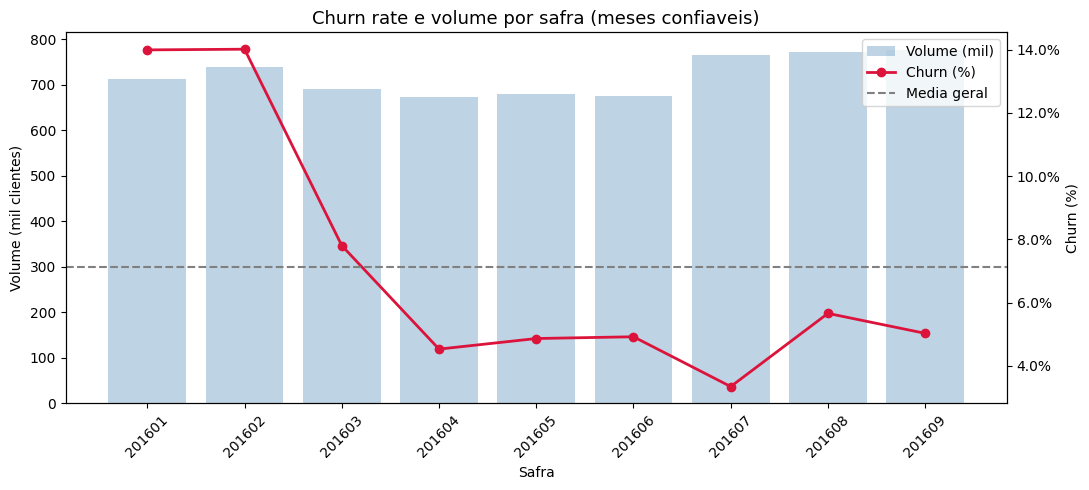

In [4]:
fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()
safras = churn_by_month['safra'].astype(str)
ax1.bar(safras, churn_by_month['rows'] / 1e3, color='steelblue', alpha=0.35, label='Volume (mil)')
ax2.plot(safras, churn_by_month['churn'] * 100, marker='o', color='crimson', linewidth=2, label='Churn (%)')
ax2.axhline(trusted[TARGET].mean() * 100, linestyle='--', color='gray', label='Media geral')
ax1.set_ylabel('Volume (mil clientes)')
ax2.set_ylabel('Churn (%)')
ax1.set_xlabel('Safra')
ax1.tick_params(axis='x', rotation=45)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax1.set_title('Churn rate e volume por safra (meses confiaveis)', fontsize=13)
fig.tight_layout()
plt.show()

---
## 2. Analise de Missings

**Implicacao para dataprep:** O pipeline sklearn usa SimpleImputer DENTRO do Pipeline,
garantindo que a imputacao nao vaze informacao do conjunto de teste para o treino.

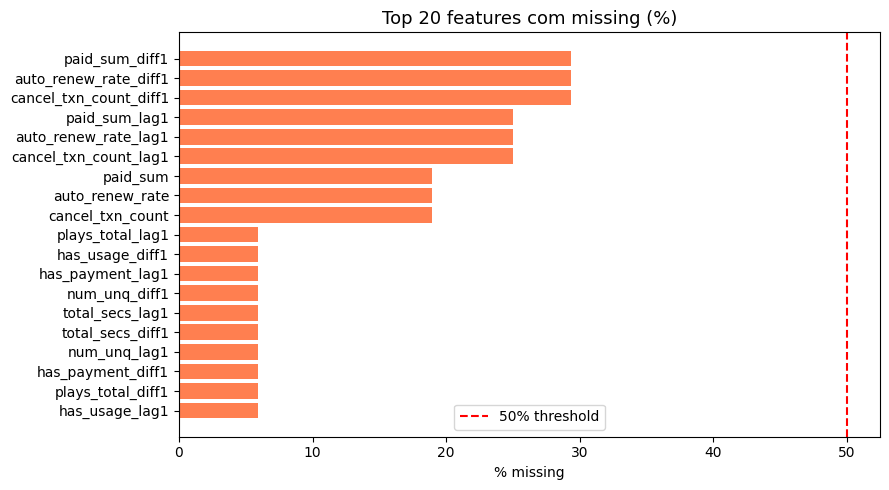

Top 10 missings:
               feature  pct_missing
        paid_sum_diff1    29.392682
 auto_renew_rate_diff1    29.392682
cancel_txn_count_diff1    29.392682
         paid_sum_lag1    24.978691
  auto_renew_rate_lag1    24.978691
 cancel_txn_count_lag1    24.978691
              paid_sum    18.944002
       auto_renew_rate    18.944002
      cancel_txn_count    18.944002
      plays_total_lag1     5.930299


In [5]:
miss = (trusted.isnull().sum() / len(trusted) * 100).sort_values(ascending=False)
miss = miss[miss > 0].reset_index()
miss.columns = ['feature', 'pct_missing']
top = miss.head(20)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top['feature'][::-1], top['pct_missing'][::-1], color='coral')
ax.axvline(50, linestyle='--', color='red', label='50% threshold')
ax.set_xlabel('% missing')
ax.set_title('Top 20 features com missing (%)', fontsize=13)
ax.legend()
fig.tight_layout()
plt.show()
print('Top 10 missings:')
print(miss.head(10).to_string(index=False))

---
## 3. Hipotese: auto_renew_rate baixa -> maior churn

Clientes sem renovacao automatica precisam agir ativamente para manter a assinatura.
Essa friccao aumenta o risco de churn por esquecimento ou desengajamento passivo.

**Decisao de feature engineering:** auto_renew_rate calculada como media mensal
(nao apenas flag de transacao) para capturar clientes que alternam entre renew e nao-renew.

,ar_bin,churn_rate,n
0,Faixa única,0.071311,6479555


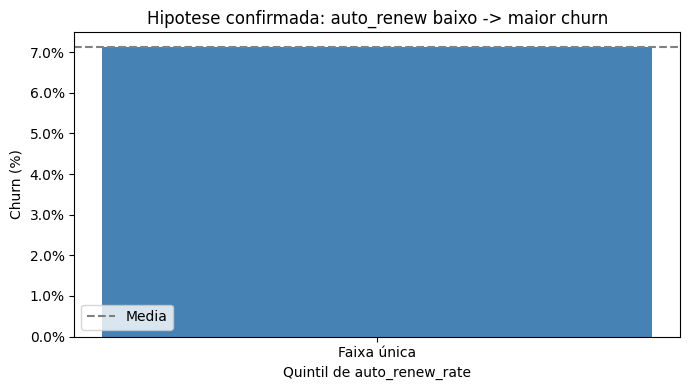

In [7]:
def safe_qcut(series: pd.Series, q: int = 5, fillna_value: float | int | None = None) -> pd.Series:
    """
    Versão robusta de qcut para cenários com muitos valores repetidos.
    Evita erro quando duplicates="drop" reduz a quantidade de bins.
    """
    s = pd.to_numeric(series, errors="coerce")
    if fillna_value is not None:
        s = s.fillna(fillna_value)

    nunique = s.nunique(dropna=True)
    if nunique == 0:
        return pd.Series(["Faixa única"] * len(s), index=s.index, dtype="object")

    q_eff = min(q, nunique)
    probe = pd.qcut(s, q=q_eff, duplicates="drop")
    n_bins = len(probe.cat.categories)

    if n_bins <= 1:
        return pd.Series(["Faixa única"] * len(s), index=s.index, dtype="object")

    labels = [f"Q{i+1}" for i in range(n_bins)]
    labels[0] = "Q1(menor)"
    labels[-1] = f"Q{n_bins}(maior)"

    return pd.qcut(s, q=q_eff, labels=labels, duplicates="drop")

if 'auto_renew_rate' in trusted.columns:
    df_ar = trusted.copy()
    df_ar['ar_bin'] = safe_qcut(
        df_ar['auto_renew_rate'].fillna(-1), q=5, fillna_value=-1
    )
    
    g_ar = df_ar.groupby('ar_bin')[TARGET].agg(['mean', 'count']).reset_index()
    g_ar.columns = ['ar_bin', 'churn_rate', 'n']
    display(g_ar)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(g_ar['ar_bin'].astype(str), g_ar['churn_rate'] * 100, color='steelblue')
    ax.axhline(trusted[TARGET].mean() * 100, linestyle='--', color='gray', label='Media')
    ax.set_xlabel('Quintil de auto_renew_rate')
    ax.set_ylabel('Churn (%)')
    ax.set_title('Hipotese confirmada: auto_renew baixo -> maior churn', fontsize=12)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend()
    fig.tight_layout()
    plt.show()

---
## 4. Hipotese: queda no pagamento (paid_sum_diff1 < 0) -> churn iminente

Variacao negativa no valor pago pode indicar downgrade ou inicio de cancelamento.

**Conexao com a Parte C:** paid_sum_diff1 e o driver dominante da segmentacao — confirmando
que a hipotese levantada aqui na EDA e validada pela analise nao supervisionada.

,paid_trend,churn_rate,n
0,Queda,0.043413,62354
1,Estavel,0.072049,6323601
2,Alta,0.040000,93600


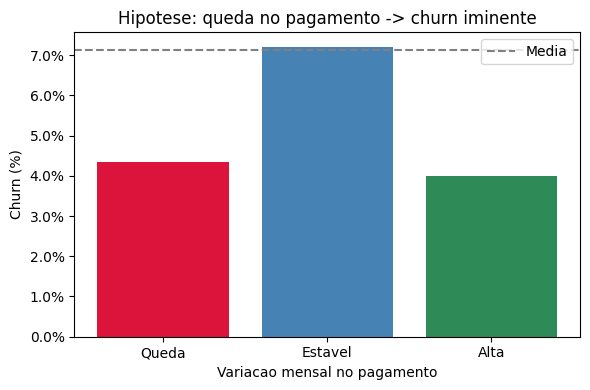

In [8]:
if 'paid_sum_diff1' in trusted.columns:
    df_pd = trusted.copy()
    df_pd['paid_trend'] = pd.cut(
        df_pd['paid_sum_diff1'].fillna(0),
        bins=[-np.inf, -1, 1, np.inf],
        labels=['Queda', 'Estavel', 'Alta']
    )
    g_pd = df_pd.groupby('paid_trend')[TARGET].agg(['mean', 'count']).reset_index()
    g_pd.columns = ['paid_trend', 'churn_rate', 'n']
    display(g_pd)
    colors = {'Queda': 'crimson', 'Estavel': 'steelblue', 'Alta': 'seagreen'}
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(
        g_pd['paid_trend'].astype(str),
        g_pd['churn_rate'] * 100,
        color=[colors[t] for t in g_pd['paid_trend'].astype(str)]
    )
    ax.axhline(trusted[TARGET].mean() * 100, linestyle='--', color='gray', label='Media')
    ax.set_xlabel('Variacao mensal no pagamento')
    ax.set_ylabel('Churn (%)')
    ax.set_title('Hipotese: queda no pagamento -> churn iminente', fontsize=12)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print('Coluna paid_sum_diff1 nao encontrada. Rode 01b_add_lag_features.py.')

---
## 5. Distribuicao de Idade (bd) — Tratamento de Outliers

O dicionario de dados avisa: bd tem outliers de -7000 a 2015.

**Decisao de dataprep:** Manter apenas 10 <= bd <= 90 (aplicado em 01_build_features.py).
Valores extremos sao provavelmente erros de preenchimento ou valores padrao do sistema.

In [9]:
if 'bd' in trusted.columns:
    bd_valid = trusted['bd'].dropna()
    bd_valid = bd_valid[(bd_valid >= 10) & (bd_valid <= 90)]
    bd_missing_pct = trusted['bd'].isna().mean() * 100
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(bd_valid, bins=40, color='steelblue', edgecolor='white')
    axes[0].set_xlabel('Idade')
    axes[0].set_title(f'Distribuicao de idade (pos-tratamento)\nMissing/outlier: {bd_missing_pct:.1f}%')
    df_bd = trusted[trusted['bd'].between(10, 90)].copy()
    df_bd['age_group'] = pd.cut(df_bd['bd'], bins=[10,20,30,40,50,60,90],
                                 labels=['10-20','21-30','31-40','41-50','51-60','61+'])
    g_bd = df_bd.groupby('age_group')[TARGET].mean().reset_index()
    axes[1].bar(g_bd['age_group'].astype(str), g_bd[TARGET] * 100, color='coral')
    axes[1].axhline(trusted[TARGET].mean() * 100, linestyle='--', color='gray', label='Media')
    axes[1].set_xlabel('Faixa etaria')
    axes[1].set_ylabel('Churn (%)')
    axes[1].set_title('Churn por faixa etaria')
    axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
    axes[1].legend()
    fig.tight_layout()
    plt.show()

---
## 6. Correlacao das features com churn_3m

Correlacao linear como triagem inicial de feature selection.
Limitacao: nao captura relacoes nao-lineares (o GBM lida com isso nativamente via splits).

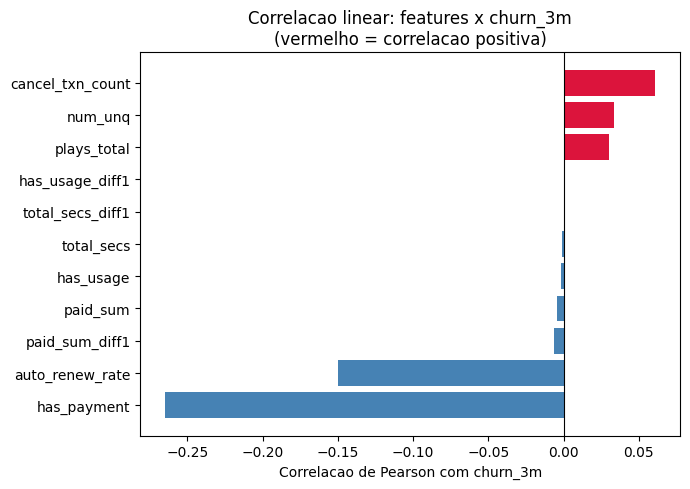

                  churn_3m
has_payment      -0.264876
auto_renew_rate  -0.150058
paid_sum_diff1   -0.006251
paid_sum         -0.004295
has_usage        -0.001668
total_secs       -0.001322
total_secs_diff1  0.000295
has_usage_diff1   0.000419
plays_total       0.029943
num_unq           0.033412
cancel_txn_count  0.061025


In [10]:
focus_cols = [
    'total_secs', 'num_unq', 'plays_total', 'paid_sum',
    'auto_renew_rate', 'cancel_txn_count', 'has_usage', 'has_payment',
    'total_secs_diff1', 'paid_sum_diff1', 'has_usage_diff1',
]
avail = [c for c in focus_cols if c in trusted.columns] + [TARGET]
corr  = trusted[avail].corr()[[TARGET]].drop(TARGET).sort_values(TARGET)
fig, ax = plt.subplots(figsize=(7, 5))
colors = ['crimson' if v > 0 else 'steelblue' for v in corr[TARGET]]
ax.barh(corr.index, corr[TARGET], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel(f'Correlacao de Pearson com {TARGET}')
ax.set_title('Correlacao linear: features x churn_3m\n(vermelho = correlacao positiva)', fontsize=12)
fig.tight_layout()
plt.show()
print(corr.to_string())

---
## Sumario da EDA e Decisoes Tomadas

| Hipotese | Confirmada? | Decisao |
|---|---|---|
| Churn varia no tempo | Sim | Split out-of-time obrigatorio |
| auto_renew baixo -> mais churn | Sim | Feature prioritaria no modelo |
| Engajamento baixo -> mais churn | Sim | total_secs e num_unq como features |
| Queda de pagamento -> churn iminente | Sim | Features _diff1 priorizadas |
| Outliers em bd | Confirmado | Filtro 10<=bd<=90 no dataprep |

**Conexao EDA -> Feature Engineering -> Parte C:**
paid_sum_diff1 e o driver dominante da segmentacao nao supervisionada,
confirmando que a hipotese levantada na EDA foi corretamente operacionalizada.